In [ ]:
import os
import time
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PATH = "../aca-butterflies"
NUM_CLASSES = 75
BATCH_SIZE = 32
IMAGE_SIZE = 224 # standard for pretrained ResNets
NUM_EPOCHS = 40
PATIENCE = 7

# since we are using pre trained resNets we decided to normalize it using this values 
# discussion of value origin can be found here https://github.com/pytorch/vision/pull/1965
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# from our dataset, calculated at 0_EDA.ipynb file
RGB_MEAN = [0.4790, 0.4646, 0.3369]
RGB_STD = [0.2560, 0.2462, 0.2558]

In [2]:
class ButterflyDataset(data.Dataset):
    def __init__(self, df, img_dir, transform=None, class_to_idx=None):
        self.img_labels = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

        self.classes = sorted(self.img_labels['label'].unique())
        self.class_to_idx = class_to_idx if class_to_idx is not None else {
            cls_name: idx for idx, cls_name in enumerate(self.classes)
        }

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_name = self.img_labels.iloc[idx]['filename']
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        label_name = self.img_labels.iloc[idx]['label']
        label_idx = self.class_to_idx[label_name]
        label = torch.tensor(label_idx, dtype=torch.long)

        if self.transform:
            image = self.transform(image)

        return image, label

In [3]:
def build_transforms(mean, std, image_size=IMAGE_SIZE):
    train = transforms.Compose([
        transforms.RandomResizedCrop(image_size, scale=(0.7, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(p=0.1),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
        transforms.RandomRotation(20),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    val = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(image_size),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    
    return train, val

In [4]:
train_transform, val_transform = build_transforms(RGB_MEAN, RGB_STD)
train_transform_pre_trained, val_transform_pre_trained = build_transforms(IMAGENET_MEAN, IMAGENET_STD)

img_dir = os.path.join(PATH, "train")
df = pd.read_csv(os.path.join(PATH, "train.csv"))

df_train, df_val = train_test_split(df, test_size=0.20, stratify=df["label"], random_state=SEED)

all_classes   = sorted(df["label"].unique())
class_to_idx  = {cls: idx for idx, cls in enumerate(all_classes)}
idx_to_class  = {idx: cls for cls, idx in class_to_idx.items()}

train_dataset = ButterflyDataset(df_train, img_dir, train_transform, class_to_idx)
val_dataset   = ButterflyDataset(df_val, img_dir, val_transform, class_to_idx)

train_dataset_pre = ButterflyDataset(df_train, img_dir, train_transform_pre_trained, class_to_idx)
val_dataset_pre   = ButterflyDataset(df_val, img_dir, val_transform_pre_trained, class_to_idx)

train_loader = data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader = data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

train_loader_pre_trained = data.DataLoader(train_dataset_pre, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader_pre_trained = data.DataLoader(val_dataset_pre, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(df_train.size)
print(df_val.size)

8318
2080


In [5]:
class BasicBlock(nn.Module):
    # He et al., 'Deep Residual Learning for Image Recognition', can be found in ../papers
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels * self.expansion:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels * self.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * self.expansion)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)   # residual addition
        return F.relu(out)


class BottleneckBlock(nn.Module):
    expansion = 4

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        width = out_channels

        self.conv1 = nn.Conv2d(in_channels, width, kernel_size=1, bias=False)
        self.bn1   = nn.BatchNorm2d(width)

        self.conv2 = nn.Conv2d(width, width, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(width)

        self.conv3 = nn.Conv2d(width, out_channels * self.expansion, kernel_size=1, bias=False)
        self.bn3   = nn.BatchNorm2d(out_channels * self.expansion)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels * self.expansion:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels * self.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * self.expansion)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = F.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        out += self.shortcut(x)
        return F.relu(out)

In [6]:
class CustomResNet(nn.Module):
    def __init__(self, block, layers, num_classes=75, dropout_p=0.4):
        super().__init__()
        self.in_channels = 64

        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        self.layer1 = self._make_layer(block, 64,  layers[0], stride=1)
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(p=dropout_p)
        self.fc = nn.Linear(512 * block.expansion, num_classes)

        # Weight initialisation (He / Kaiming)
        # Delving deep into rectifiers: Surpassing human-level performance on ImageNet classification by He et al, can be found in ./papers
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers  = []
        for s in strides:
            layers.append(block(self.in_channels, out_channels, stride=s))
            self.in_channels = out_channels * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        return self.fc(x)


def resnet18_custom(num_classes=75, dropout_p=0.4):
    return CustomResNet(BasicBlock, [2, 2, 2, 2], num_classes, dropout_p)

def resnet34_custom(num_classes=75, dropout_p=0.4):
    return CustomResNet(BasicBlock, [3, 4, 6, 3], num_classes, dropout_p)

def resnet50_custom(num_classes=75, dropout_p=0.4):
    return CustomResNet(BottleneckBlock, [3, 4, 6, 3], num_classes, dropout_p)



In [7]:
def build_pretrained_resnet(variant="resnet18", strategy="finetune", num_classes=75, dropout_p=0.4):
    weights_map = {
        "resnet18": models.ResNet18_Weights.DEFAULT,
        "resnet50": models.ResNet50_Weights.DEFAULT,
    }
    constructor_map = {
        "resnet18": models.resnet18,
        "resnet50": models.resnet50,
    }

    model = constructor_map[variant](weights=weights_map[variant])

    if strategy == "freeze":
        for param in model.parameters():
            param.requires_grad = False

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=dropout_p),
        nn.Linear(in_features, num_classes)
    )
    return model


In [8]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += images.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_labels, all_preds = [], []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss    = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += images.size(0)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

    avg_loss = total_loss / total
    acc = correct / total
    return avg_loss, acc, np.array(all_labels), np.array(all_preds)

In [9]:
def compute_metrics(labels, preds, name=""):
    acc = accuracy_score(labels, preds)
    f1_mac = f1_score(labels, preds, average="macro",  zero_division=0)
    f1_wei = f1_score(labels, preds, average="weighted", zero_division=0)

    print(f"{name}->Accuracy : {acc:.4f}")
    print(f"{name}->F1 (macro) : {f1_mac:.4f}")
    print(f"{name}->F1(weighted) : {f1_wei:.4f}")
    return {"accuracy": acc, "f1_macro": f1_mac, "f1_weighted": f1_wei}


def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler=None, num_epochs=NUM_EPOCHS, patience=PATIENCE, device=DEVICE, run_name="experiment"):
    counter_early_stopper = 0
    best_weights = None
    best_loss = float("inf")
    history = {"train_loss": [], "val_loss": [], "train_acc":  [], "val_acc":  []}

    t0 = time.time()
    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        vl_loss, vl_acc, *_ = evaluate(model, val_loader, criterion, device)

        if scheduler is not None:
            scheduler.step()

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)

        print(f"Epoch {epoch:3d}/{num_epochs} | Train loss: {tr_loss:.4f} acc: {tr_acc:.4f} | Val loss: {vl_loss:.4f} acc: {vl_acc:.4f}")
        
        if vl_loss < best_loss - 1e-4:
            best_loss = vl_loss
            best_weights = copy.deepcopy(model.state_dict())
            counter_early_stopper = 0
        else:
            counter_early_stopper += 1
            if counter_early_stopper >= patience:
                print(f"Early stopped at epoch {epoch}")
                break

    elapsed = time.time() - t0
    elapsed_in_min = elapsed/60
    print(f"Training complete in {elapsed_in_min:.1f} minutes")

    model.load_state_dict(best_weights)
    return model, history, elapsed_in_min

In [10]:
def plot_history(history, title="Training History"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history["train_loss"]) + 1)

    axes[0].plot(epochs, history["train_loss"], label="Train")
    axes[0].plot(epochs, history["val_loss"],   label="Val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(epochs, history["train_acc"], label="Train")
    axes[1].plot(epochs, history["val_acc"],   label="Val")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

In [ ]:
def build_optimizer(name, params, lr, weight_decay=1e-4):
    if name == "adam":
        return torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)
    elif name == "rmsprop":
        return torch.optim.RMSprop(params, lr=lr, weight_decay=weight_decay, momentum=0.9)


def build_criterion(name):
    if name == "cross_entropy":
        return nn.CrossEntropyLoss(label_smoothing=0.1)
    elif name == "multi_margin":
        return nn.MultiMarginLoss(margin=1.0)

exp = [
    # (run_name, model_fn, loss_name, optim_name, lr, flag_pretrained)
    #("custom_resnet18_ce_adam", lambda: resnet18_custom(), "cross_entropy", "adam", 1e-3, 0),
    #("custom_resnet18_ce_rmsprop", lambda: resnet18_custom(), "cross_entropy", "rmsprop", 1e-3, 0),
    #("custom_resnet18_mm_adam", lambda: resnet18_custom(), "multi_margin",  "adam", 1e-3, 0),
    #("custom_resnet34_ce_adam", lambda: resnet34_custom(), "cross_entropy", "adam", 1e-3, 0),
    ("custom_resnet50_ce_adam", lambda: resnet50_custom(), "cross_entropy", "adam", 1e-3, 0),
    #("custom_resnet34_mm_adam", lambda: resnet34_custom(), "multi_margin", "adam", 1e-3, 0)
    #("pretrained_resnet18_ce_adam", lambda: build_pretrained_resnet("resnet18", "finetune"), "cross_entropy", "adam", 1e-4, 1),
    #("pretrained_resnet18_ce_rmsprop", lambda: build_pretrained_resnet("resnet18", "finetune"), "cross_entropy", "rmsprop", 1e-4, 1),
    #("pretrained_resnet18_mm_adam", lambda: build_pretrained_resnet("resnet18", "finetune"), "multi_margin",  "adam", 1e-4, 1),
    #("pretrained_resnet50_ce_adam", lambda: build_pretrained_resnet("resnet50", "finetune"), "cross_entropy", "adam", 1e-4, 1),
    #("pretrained_resnet18_freezed_ce_adam", lambda: build_pretrained_resnet("resnet18", "freeze"), "cross_entropy",  "adam", 1e-4, 1),
    #("pretrained_resnet50_freezed_ce_adam", lambda: build_pretrained_resnet("resnet50", "freeze"), "cross_entropy", "adam", 1e-4, 1),
]


-------------------------------------
Run: pretrained_resnet18_ce_adam
Loss: cross_entropy  |  Optimizer: adam  |  LR: 0.0001
----------------------------------------------
Epoch   1/40 | Train loss: 3.1160 acc: 0.3724 | Val loss: 1.7361 acc: 0.7913
Epoch   2/40 | Train loss: 1.6555 acc: 0.7853 | Val loss: 1.2792 acc: 0.8558
Epoch   3/40 | Train loss: 1.3092 acc: 0.8663 | Val loss: 1.1706 acc: 0.8990
Epoch   4/40 | Train loss: 1.1729 acc: 0.9036 | Val loss: 1.1234 acc: 0.9000
Epoch   5/40 | Train loss: 1.1041 acc: 0.9223 | Val loss: 1.0968 acc: 0.9183
Epoch   6/40 | Train loss: 1.0488 acc: 0.9413 | Val loss: 1.0800 acc: 0.9231
Epoch   7/40 | Train loss: 1.0046 acc: 0.9598 | Val loss: 1.0587 acc: 0.9279
Epoch   8/40 | Train loss: 0.9939 acc: 0.9618 | Val loss: 1.0515 acc: 0.9308
Epoch   9/40 | Train loss: 0.9723 acc: 0.9668 | Val loss: 1.0477 acc: 0.9365
Epoch  10/40 | Train loss: 0.9634 acc: 0.9721 | Val loss: 1.0463 acc: 0.9337
Epoch  11/40 | Train loss: 1.0150 acc: 0.9524 | Val loss:

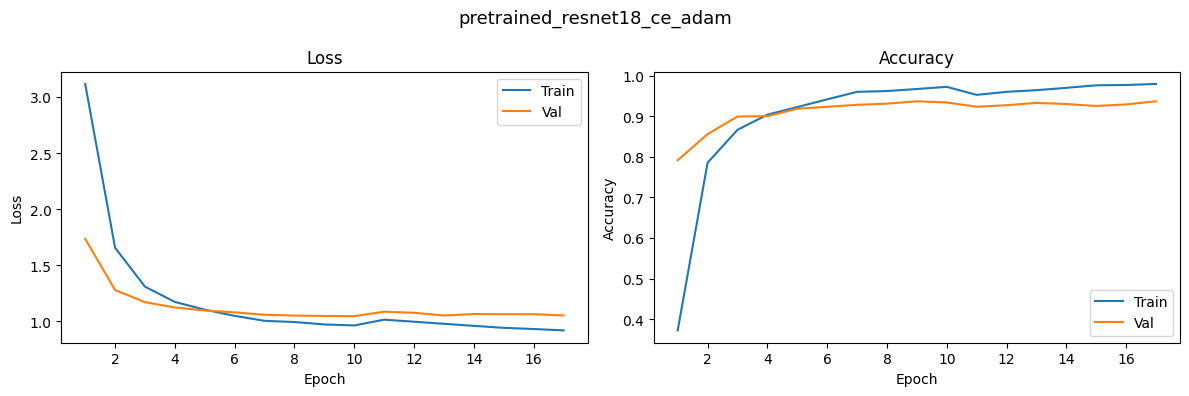

Checkpoint saved: checkpoints_ResNets2026/pretrained_resnet18_ce_adam.pt
-------------------------------------
Run: pretrained_resnet50_ce_adam
Loss: cross_entropy  |  Optimizer: adam  |  LR: 0.0001
----------------------------------------------
Epoch   1/40 | Train loss: 3.3918 acc: 0.3345 | Val loss: 1.6396 acc: 0.7846
Epoch   2/40 | Train loss: 1.4567 acc: 0.8163 | Val loss: 1.1590 acc: 0.8885
Epoch   3/40 | Train loss: 1.1320 acc: 0.8985 | Val loss: 1.0637 acc: 0.9019
Epoch   4/40 | Train loss: 1.0238 acc: 0.9368 | Val loss: 1.0223 acc: 0.9317
Epoch   5/40 | Train loss: 0.9595 acc: 0.9598 | Val loss: 0.9976 acc: 0.9337
Epoch   6/40 | Train loss: 0.9183 acc: 0.9695 | Val loss: 0.9734 acc: 0.9423
Epoch   7/40 | Train loss: 0.8865 acc: 0.9791 | Val loss: 0.9608 acc: 0.9481
Epoch   8/40 | Train loss: 0.8710 acc: 0.9849 | Val loss: 0.9523 acc: 0.9519
Epoch   9/40 | Train loss: 0.8590 acc: 0.9863 | Val loss: 0.9482 acc: 0.9529
Epoch  10/40 | Train loss: 0.8586 acc: 0.9858 | Val loss: 0.9

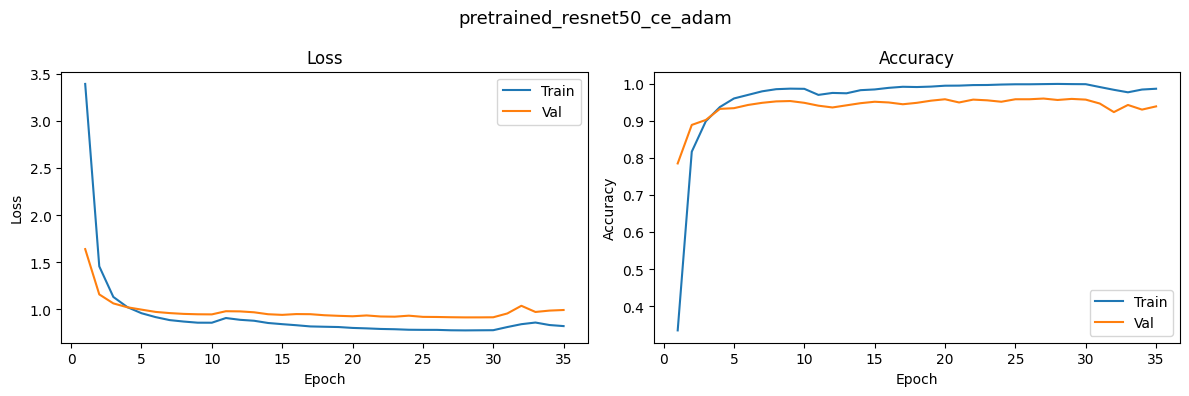

Checkpoint saved: checkpoints_ResNets2026/pretrained_resnet50_ce_adam.pt
pretrained_resnet18_ce_adam->3.1693310340245566
pretrained_resnet50_ce_adam->19.415567870934805


In [ ]:
results_summary = []
trained_models = {}
all_histories = {}
all_time = {}

for run_name, model_fn, loss_name, optim_name, lr, flag_pretrained in exp:
    print("-------------------------------------")
    print(f"Run: {run_name}")
    print(f"Loss: {loss_name}  |  Optimizer: {optim_name}  |  LR: {lr}")
    print("----------------------------------------------")
    
    if flag_pretrained:
        train_loader_use = train_loader_pre_trained
        val_loader_use = val_loader_pre_trained
    else:
        train_loader_use = train_loader
        val_loader_use = val_loader

    model = model_fn().to(DEVICE)
    criterion = build_criterion(loss_name)
    optimizer = build_optimizer(optim_name, model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=lr * 0.01)

    model, history, time_var = train_model(model, train_loader_use, val_loader_use, criterion, optimizer, scheduler=scheduler, run_name=run_name)

    _, _, labels, preds = evaluate(model, val_loader_use, criterion, DEVICE)
    metrics = compute_metrics(labels, preds, name=run_name)

    results_summary.append({
        "run"         : run_name,
        "loss"        : loss_name,
        "optimizer"   : optim_name,
        "lr"          : lr,
        **metrics
    })
    trained_models[run_name] = model
    all_histories[run_name]  = history
    all_time[run_name] = time_var

    plot_history(history, title=run_name)

    # Save checkpoint
    os.makedirs(f"../checkpoints_ResNets/checkpoints_ResNets_{SEED}", exist_ok=True)
    torch.save({"model_state": model.state_dict(), "history": history, "f1_macro" : metrics["f1_macro"], "f1_weighted" : metrics["f1_weighted"]}, f"../checkpoints_ResNets/checkpoints_ResNets_{SEED}/{run_name}.pt")
    print(f"Checkpoint saved: checkpoints_ResNets_{SEED}/{run_name}.pt")

for key, value in all_time.items():
    print(f"{key}->{value}")

In [13]:
df_results = pd.DataFrame(results_summary).sort_values("accuracy", ascending=False)
df_results = df_results.reset_index(drop=True)

pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", "{:.4f}".format)
print(df_results.to_string(index=False))

                        run          loss optimizer     lr  accuracy  f1_macro  f1_weighted
pretrained_resnet50_ce_adam cross_entropy      adam 0.0001    0.9558    0.9555       0.9554
pretrained_resnet18_ce_adam cross_entropy      adam 0.0001    0.9337    0.9336       0.9334


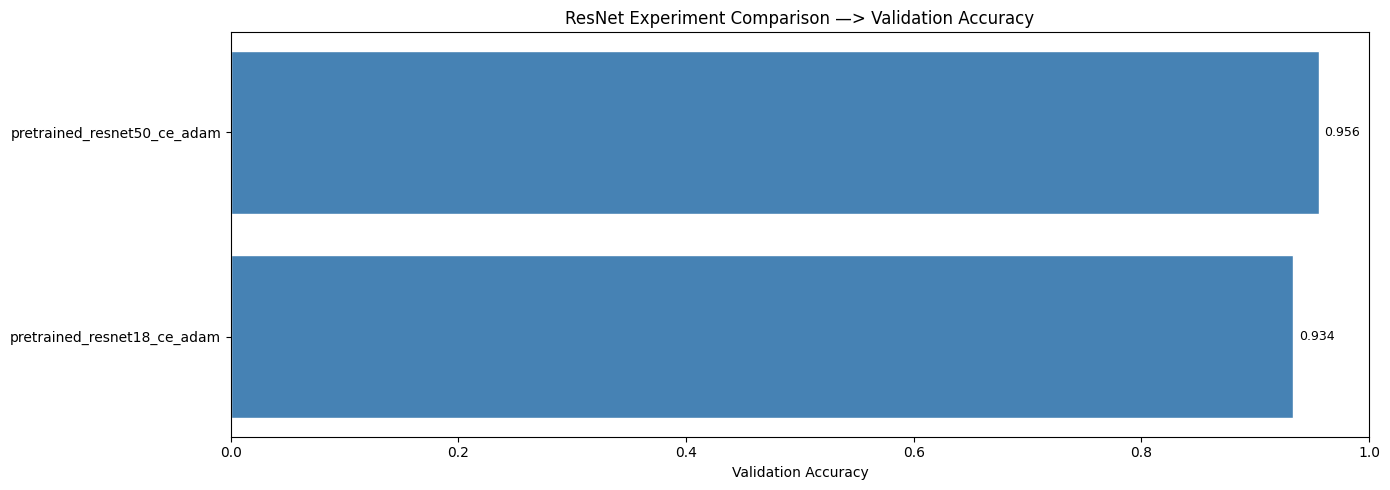

In [14]:
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.barh(df_results["run"][::-1], df_results["accuracy"][::-1], color="steelblue", edgecolor="white")
ax.set_xlabel("Validation Accuracy")
ax.set_title("ResNet Experiment Comparison —> Validation Accuracy")
ax.set_xlim(0, 1.0)
for bar, val in zip(bars, df_results["accuracy"][::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2, f"{val:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

In [15]:
best_run  = df_results.iloc[0]["run"]
best_model = trained_models[best_run]
print(f"Best model: {best_run}\n")

best_loss_name = df_results.iloc[0]["loss"]
criterion_best = build_criterion(best_loss_name)


if best_run.startswith("pretrained"):
    val_loader_use = val_loader_pre_trained
else:
    val_loader_use = val_loader

_, _, labels, preds, = evaluate(best_model, val_loader_use, criterion_best, DEVICE)

print(classification_report(labels, preds, target_names=[idx_to_class[i] for i in range(NUM_CLASSES)], zero_division=0))

Best model: pretrained_resnet50_ce_adam

                           precision    recall  f1-score   support

                   ADONIS       0.82      1.00      0.90        14
AFRICAN GIANT SWALLOWTAIL       0.92      0.92      0.92        12
           AMERICAN SNOOT       0.92      1.00      0.96        12
                    AN 88       1.00      1.00      1.00        14
                  APPOLLO       1.00      1.00      1.00        14
                    ATALA       0.94      1.00      0.97        16
 BANDED ORANGE HELICONIAN       1.00      1.00      1.00        16
           BANDED PEACOCK       0.92      0.85      0.88        13
            BECKERS WHITE       0.93      1.00      0.96        13
         BLACK HAIRSTREAK       1.00      0.93      0.96        14
              BLUE MORPHO       0.86      1.00      0.92        12
        BLUE SPOTTED CROW       0.93      0.93      0.93        14
           BROWN SIPROETA       0.94      0.94      0.94        16
            CABBAGE 

In [16]:
second_run  = df_results.iloc[1]["run"]
second_model = trained_models[second_run]
print(f"Second best model: {second_run}\n")

second_loss_name = df_results.iloc[1]["loss"]
criterion_second = build_criterion(second_loss_name)


if second_run.startswith("pretrained"):
    val_loader_use = val_loader_pre_trained
else:
    val_loader_use = val_loader

_, _, labels, preds = evaluate(second_model, val_loader_use, criterion_second, DEVICE)

print(classification_report(labels, preds, target_names=[idx_to_class[i] for i in range(NUM_CLASSES)], zero_division=0))

Second best model: pretrained_resnet18_ce_adam

                           precision    recall  f1-score   support

                   ADONIS       0.88      1.00      0.93        14
AFRICAN GIANT SWALLOWTAIL       1.00      1.00      1.00        12
           AMERICAN SNOOT       0.92      1.00      0.96        12
                    AN 88       1.00      1.00      1.00        14
                  APPOLLO       0.93      1.00      0.97        14
                    ATALA       1.00      0.94      0.97        16
 BANDED ORANGE HELICONIAN       0.89      1.00      0.94        16
           BANDED PEACOCK       1.00      0.92      0.96        13
            BECKERS WHITE       0.92      0.92      0.92        13
         BLACK HAIRSTREAK       0.92      0.86      0.89        14
              BLUE MORPHO       0.85      0.92      0.88        12
        BLUE SPOTTED CROW       0.87      0.93      0.90        14
           BROWN SIPROETA       0.94      0.94      0.94        16
            C

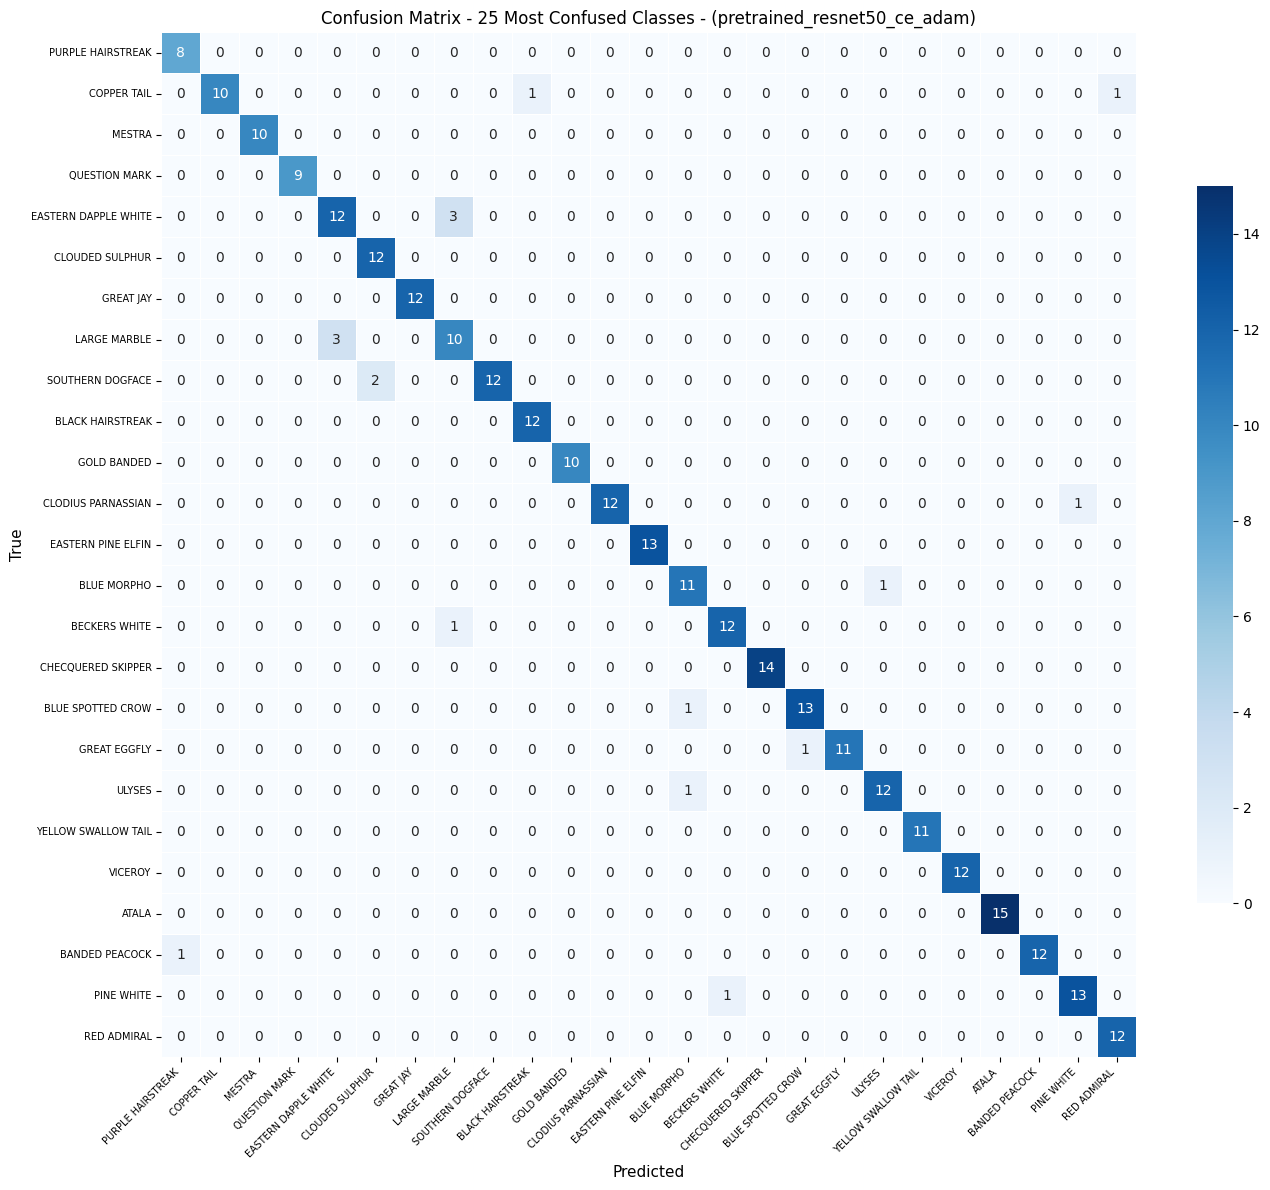

In [17]:
cm = confusion_matrix(labels, preds)

errors_per_class = cm.sum(axis=1) - cm.diagonal()
top25_idx = np.argsort(errors_per_class)[-25:][::-1]

cm_top25    = cm[np.ix_(top25_idx, top25_idx)]
class_names = [idx_to_class[i] for i in top25_idx]

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm_top25, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=ax, linewidths=0.4, cbar_kws={"shrink": 0.7})
ax.set_xlabel("Predicted", fontsize=11)
ax.set_ylabel("True", fontsize=11)
ax.set_title(f"Confusion Matrix - 25 Most Confused Classes - ({best_run})")
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_552801/712109069.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


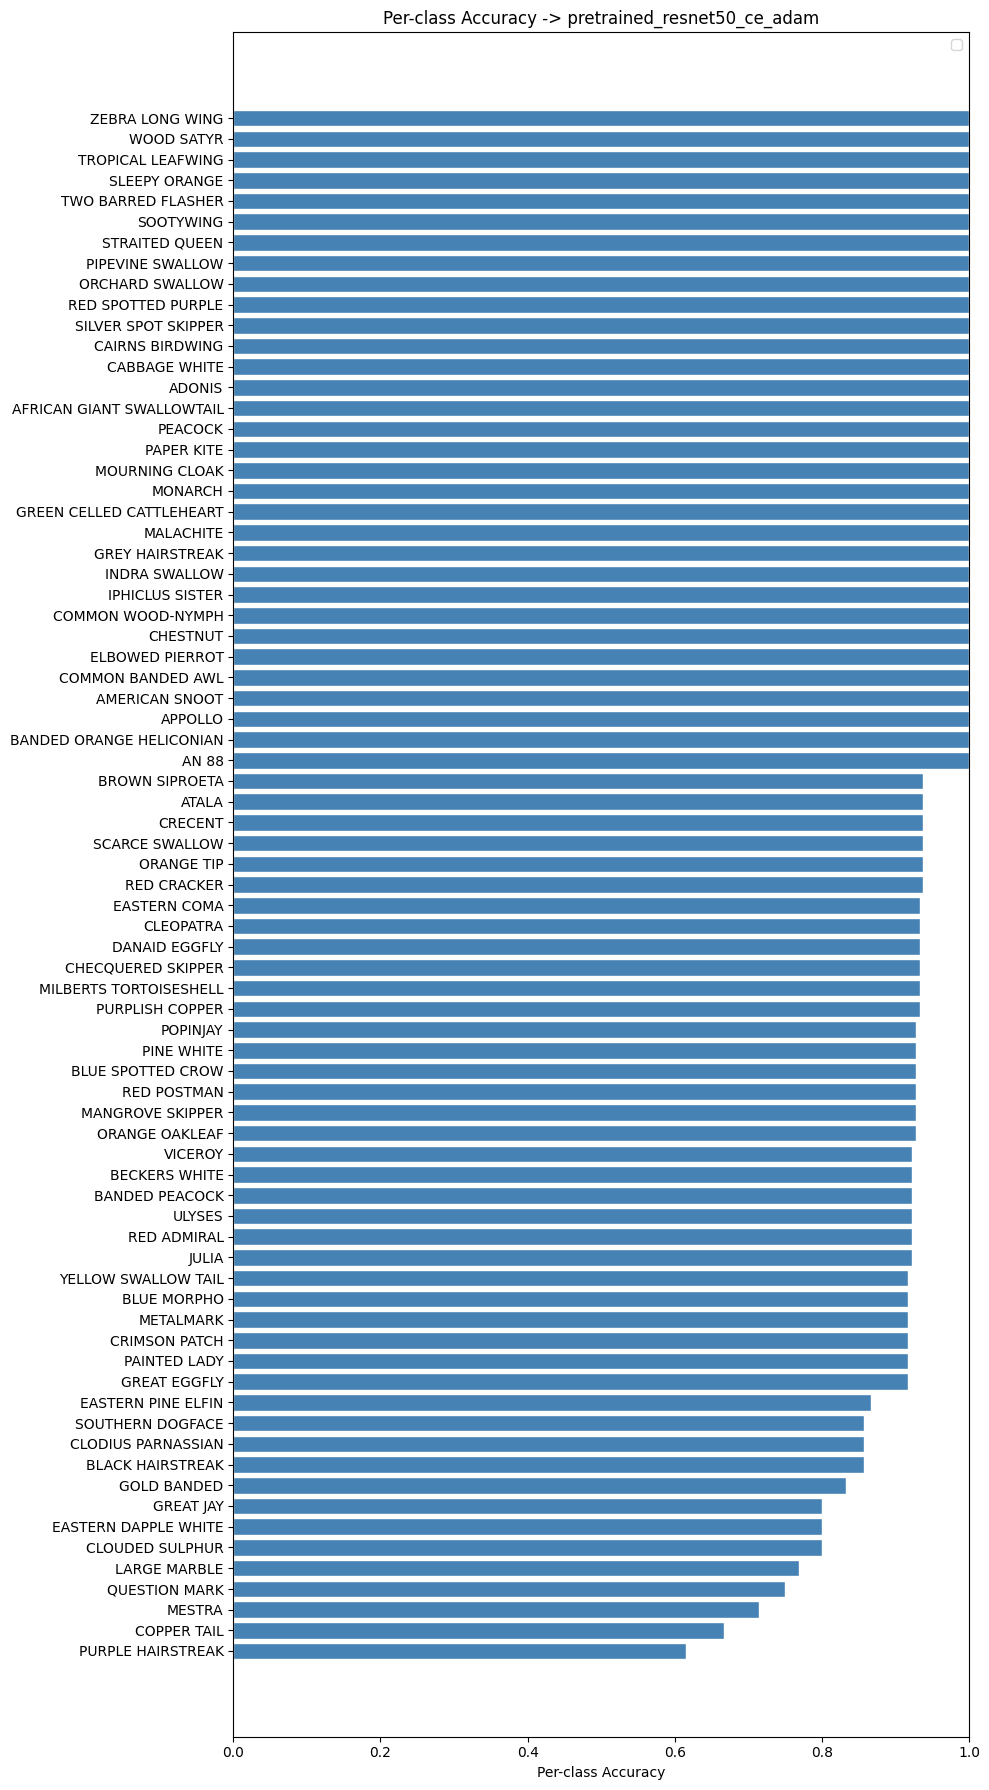

In [18]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

sorted_idx = np.argsort(per_class_acc)
sorted_acc = per_class_acc[sorted_idx]
sorted_names = [idx_to_class[i] for i in sorted_idx]

fig, ax = plt.subplots(figsize=(10, 18))
colors = ["tomato" if a < 0.5 else "steelblue" for a in sorted_acc]
ax.barh(sorted_names, sorted_acc, color=colors, edgecolor="white")
ax.set_xlabel("Per-class Accuracy")
ax.set_title(f"Per-class Accuracy -> {best_run}")
ax.set_xlim(0, 1.0)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
class ButterflyTestDataset(data.Dataset):
    def __init__(self, img_dir, filenames, transform=None):
        self.img_dir   = img_dir
        self.filenames = filenames
        self.transform = transform

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.filenames[idx])
        image    = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, self.filenames[idx]


@torch.no_grad()
def generate_submission(model, test_dir, class_to_idx, transform, device, output_path):
    idx_to_class_local = {v: k for k, v in class_to_idx.items()}

    filenames = sorted(os.listdir(test_dir))
    test_ds = ButterflyTestDataset(test_dir, filenames, transform)
    test_loader = data.DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    model.eval()
    ids, preds_list = [], []

    for images, fnames in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()

        ids.extend(fnames)
        preds_list.extend([idx_to_class_local[p] for p in preds])

    df_sub = pd.DataFrame({"filename": ids, "label": preds_list})
    df_sub.to_csv(output_path, index=False)
    print(f"Submission saved to {output_path} ({len(df_sub)} samples)")
    return df_sub

if best_run.startswith("pretrained"):
    val_transform_use = val_transform_pre_trained
else:
    val_transform_use = val_transform

if second_run.startswith("pretrained"):
    val_transform_use_1 = val_transform_pre_trained
else:
    val_transform_use_1 = val_transform

test_dir = os.path.join(PATH, "test")
df_submission = generate_submission(best_model, test_dir, class_to_idx, val_transform_use, DEVICE, output_path=f"../submissions_ResNets/submission_resnet_best_{SEED}.csv")
df_second = generate_submission(second_model, test_dir, class_to_idx, val_transform_use_1, DEVICE, output_path=f"../submissions_ResNets/submission_resnet_2ndbest_{SEED}.csv")

Submission saved to submission_resnet_best_2026.csv (1300 samples)
Submission saved to submission_resnet_2ndbest_2026.csv (1300 samples)
